In [1]:
from dotenv import load_dotenv
import os

from IPython.display import HTML, Markdown, display
import pandas as pd
import openai

# Add this line to load variables from .env file
load_dotenv()

GOOGLE_API_KEY = os.getenv('GOOGLE_API_KEY')  # Retrieve the API key
OPENAI_API_KEY = os.getenv('OPENAI_API_KEY')  # Retrieve the API key
LANGSMITH_API_KEY = os.getenv('LANGSMITH_API_KEY')  # Retrieve the API key
TAVILY_API_KEY = os.getenv("TAVILY_API_KEY")
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY")


### langchain

In [2]:
import getpass
import os

# una forma alternativa de cargar las variables de entorno:os.environ devuelve un dict con las variables de entorno, 
# y os.getenv devuelve el valor de una variable de entorno.

try:
    # load environment variables from .env file (requires `python-dotenv`)
    from dotenv import load_dotenv

    load_dotenv()
except ImportError:
    pass

os.environ["LANGSMITH_TRACING"] = "true"
if "LANGSMITH_API_KEY" not in os.environ:
    os.environ["LANGSMITH_API_KEY"] = getpass.getpass(
        prompt="Enter your LangSmith API key (optional): "
    )
if "LANGSMITH_PROJECT" not in os.environ:
    os.environ["LANGSMITH_PROJECT"] = getpass.getpass(
        prompt='Enter your LangSmith Project Name (default = "default"): '
    )
    if not os.environ.get("LANGSMITH_PROJECT"):
        os.environ["LANGSMITH_PROJECT"] = "default"
if "OPENAI_API_KEY" not in os.environ:
    os.environ["OPENAI_API_KEY"] = getpass.getpass(
        prompt="Enter your OpenAI API key (required if using OpenAI): "
    )


In [3]:
from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4o-mini", model_provider="openai")

In [4]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage("Translate the following from English into Italian"),
    HumanMessage("hi!"),
]

model.invoke(messages)

AIMessage(content='Ciao!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 4, 'prompt_tokens': 20, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BSujNqYt7oZQsHXMZAyR3ZbPLMObk', 'finish_reason': 'stop', 'logprobs': None}, id='run-452ec0dc-cbc9-43dc-b313-9694bb09b7f5-0', usage_metadata={'input_tokens': 20, 'output_tokens': 4, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_core.prompts import ChatPromptTemplate

system_template = "Translate the following from English into {language}"

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template), ("user", "{text}")]
)

In [6]:
from langchain_core.prompts import ChatPromptTemplate

template = ChatPromptTemplate([
    ("system", "You are a helpful AI bot. Your name is {name}."),
    ("human", "Hello, how are you doing?"),
    ("ai", "I'm doing well, thanks!"),
    ("human", "{user_input}"),
])

prompt_value = template.invoke(
    {
        "name": "Bob",
        "user_input": "What is your name?"
    }
)

prompt_value
# Output:
# ChatPromptValue(
#    messages=[
#        SystemMessage(content='You are a helpful AI bot. Your name is Bob.'),
#        HumanMessage(content='Hello, how are you doing?'),
#        AIMessage(content="I'm doing well, thanks!"),
#        HumanMessage(content='What is your name?')
#    ]
#)

ChatPromptValue(messages=[SystemMessage(content='You are a helpful AI bot. Your name is Bob.', additional_kwargs={}, response_metadata={}), HumanMessage(content='Hello, how are you doing?', additional_kwargs={}, response_metadata={}), AIMessage(content="I'm doing well, thanks!", additional_kwargs={}, response_metadata={}), HumanMessage(content='What is your name?', additional_kwargs={}, response_metadata={})])

In [7]:
prompt = prompt_template.invoke({"language": "Italian", "text": "hi!"})

prompt.to_messages()

[SystemMessage(content='Translate the following from English into Italian', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='hi!', additional_kwargs={}, response_metadata={})]

In [8]:
response = model.invoke(prompt)
print(response.content)

Ciao!


In [9]:
model.invoke([HumanMessage(content="What's my name?")])

AIMessage(content='I don’t know your name unless you tell me. How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 11, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BSujOznTQK5nneigfPbXXbURMZa8q', 'finish_reason': 'stop', 'logprobs': None}, id='run-d6e51677-2d73-46e8-b33b-63d666a0991f-0', usage_metadata={'input_tokens': 11, 'output_tokens': 19, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [10]:
from langchain_core.messages import AIMessage

model.invoke(
    [
        HumanMessage(content="Hi! I'm Bob"),
        AIMessage(content="Hello Bob! How can I assist you today?"),
        HumanMessage(content="What's my name?"),
    ]
)

AIMessage(content='Your name is Bob! How can I help you today, Bob?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 33, 'total_tokens': 48, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0392822090', 'id': 'chatcmpl-BSujPgDBPiHl2qz16guI7SVDVgUWu', 'finish_reason': 'stop', 'logprobs': None}, id='run-daa89d16-4493-4b33-8443-8e2c908973f8-0', usage_metadata={'input_tokens': 33, 'output_tokens': 15, 'total_tokens': 48, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [11]:
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import START, MessagesState, StateGraph

# Define a new graph
workflow = StateGraph(state_schema=MessagesState)


# Define the function that calls the model
def call_model(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": response}


# Define the (single) node in the graph
workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

# Add memory
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

# add thread_id to the config to support multiple conversations
config = {"configurable": {"thread_id": "abc123"}}

In [12]:
query = "Hi! I'm Bob."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()  # output contains all messages in state

================================== Ai Message ==================================

Hi Bob! How can I help you today?


In [13]:
query = "What's my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is Bob! How can I assist you today?


In [14]:
# different thread_id!
config = {"configurable": {"thread_id": "abc234"}}

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

I'm sorry, but I don't know your name. How can I assist you today?


In [15]:
# and retrun to the older thread: 
config = {"configurable": {"thread_id": "abc123"}}

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Your name is still Bob! What would you like to talk about?


In [16]:
## crear un template para el prompt
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You talk like a pirate, but in Spanish. Answer all questions to the best of your ability.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [17]:
# define la gráfica nueva, que llama al prompt template y luego al modelo

workflow = StateGraph(state_schema=MessagesState)


def call_model(state: MessagesState):
    prompt = prompt_template.invoke(state)
    response = model.invoke(prompt)
    return {"messages": response}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [18]:
config = {"configurable": {"thread_id": "abc345"}}
query = "Hola, me llamo Pepe."

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Ahoy, Pepe! ¡Bienvenido a bordo del barco de los piratas! ¿Qué aventuras te traen a estas aguas turbulentas?


In [19]:
query = "What is my name?"

input_messages = [HumanMessage(query)]
output = app.invoke({"messages": input_messages}, config)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Arrr, tu nombre es Pepe! ¿Qué más quieres saber o de qué aventuras te gustaría hablar, amigo?


In [20]:
# un prompt más complejo
prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful assistant. Answer all questions to the best of your ability in {language}.",
        ),
        MessagesPlaceholder(variable_name="messages"),
    ]
)

In [21]:
# una gráfica nueva que ahora incluye el lenguaje como variable

from typing import Sequence

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages
from typing_extensions import Annotated, TypedDict


class State(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]
    language: str


workflow = StateGraph(state_schema=State)


def call_model(state: State):
    prompt = prompt_template.invoke(state)
    response = model.invoke(prompt)
    return {"messages": [response]}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [22]:
config = {"configurable": {"thread_id": "abc456"}}
query = "Hi! I'm Bob."
language = "Spanish"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

¡Hola, Bob! ¿Cómo puedo ayudarte hoy?


In [23]:
query = "What is my name?"
language = "Swedish"

input_messages = [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Ditt namn är Bob. Hur kan jag hjälpa dig idag, Bob?


In [24]:
# acortar los mensajes a un límite de tokens para no exceder la ventana del modelo

from langchain_core.messages import SystemMessage, trim_messages

trimmer = trim_messages(
    max_tokens=65,
    strategy="last",
    token_counter=model,
    include_system=True,
    allow_partial=False,
    start_on="human",
)

messages = [
    SystemMessage(content="you're a good assistant"),
    HumanMessage(content="hi! I'm bob"),
    AIMessage(content="hi!"),
    HumanMessage(content="I like vanilla ice cream"),
    AIMessage(content="nice"),
    HumanMessage(content="whats 2 + 2"),
    AIMessage(content="4"),
    HumanMessage(content="thanks"),
    AIMessage(content="no problem!"),
    HumanMessage(content="having fun?"),
    AIMessage(content="yes!"),
]

trimmer.invoke(messages)

[SystemMessage(content="you're a good assistant", additional_kwargs={}, response_metadata={}),
 HumanMessage(content='whats 2 + 2', additional_kwargs={}, response_metadata={}),
 AIMessage(content='4', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='thanks', additional_kwargs={}, response_metadata={}),
 AIMessage(content='no problem!', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='having fun?', additional_kwargs={}, response_metadata={}),
 AIMessage(content='yes!', additional_kwargs={}, response_metadata={})]

In [25]:
# el trimmer va antes del modelo
workflow = StateGraph(state_schema=State)

def call_model(state: State):
    trimmed_messages = trimmer.invoke(state["messages"])
    prompt = prompt_template.invoke(
        {"messages": trimmed_messages, "language": state["language"]}
    )
    response = model.invoke(prompt)
    return {"messages": [response]}


workflow.add_edge(START, "model")
workflow.add_node("model", call_model)

memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

In [26]:
# el modelo olvidó el nombre porque ya pasó el límite del trimmer
config = {"configurable": {"thread_id": "abc567"}}
query = "What is my name?"
language = "French"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

Je ne connais pas votre nom. Comment vous appelez-vous ?


In [27]:
config = {"configurable": {"thread_id": "abc678"}}
query = "What math problem did I ask?"
language = "English"

input_messages = messages + [HumanMessage(query)]
output = app.invoke(
    {"messages": input_messages, "language": language},
    config,
)
output["messages"][-1].pretty_print()

================================== Ai Message ==================================

It seems you haven't asked a math problem yet. If you have one in mind, feel free to share it, and I'll be happy to help!


### Agentes

In [28]:
### Agentes

# Import relevant functionality
from langchain_anthropic import ChatAnthropic
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# Create the agent
memory = MemorySaver()
model = ChatAnthropic( api_key=os.environ.get("ANTHROPIC_API_KEY"),  model_name="claude-3-7-sonnet-20250219")
search = TavilySearchResults(max_results=2)
tools = [search]
agent_executor = create_react_agent(model, tools, checkpointer=memory)

In [29]:
# tavily es un buscador de información para los agentes

from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(max_results=2)
search_results = search.invoke("what is the weather in SF?")
print(search_results)
# If we want, we can create other tools.
# Once we have all the tools we want, we can put them in a list that we will reference later.
tools = [search]


[{'url': 'https://www.weatherapi.com/', 'content': "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1746230969, 'localtime': '2025-05-02 17:09'}, 'current': {'last_updated_epoch': 1746230400, 'last_updated': '2025-05-02 17:00', 'temp_c': 15.6, 'temp_f': 60.1, 'is_day': 1, 'condition': {'text': 'Partly cloudy', 'icon': '//cdn.weatherapi.com/weather/64x64/day/116.png', 'code': 1003}, 'wind_mph': 16.8, 'wind_kph': 27.0, 'wind_degree': 273, 'wind_dir': 'W', 'pressure_mb': 1016.0, 'pressure_in': 30.01, 'precip_mm': 0.0, 'precip_in': 0.0, 'humidity': 69, 'cloud': 75, 'feelslike_c': 15.6, 'feelslike_f': 60.1, 'windchill_c': 11.3, 'windchill_f': 52.4, 'heatindex_c': 13.1, 'heatindex_f': 55.6, 'dewpoint_c': 10.5, 'dewpoint_f': 50.9, 'vis_km': 16.0, 'vis_miles': 9.0, 'uv': 2.4, 'gust_mph': 21.2, 'gust_kph': 34.1}}"}, {'url': 'https://www.accuweather.com/en/us/

In [30]:
# Use the agent
config = {"configurable": {"thread_id": "abc123"}}
for step in agent_executor.stream(
    {"messages": [HumanMessage(content="hi im bob! and i live in sf")]},
    config,
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

hi im bob! and i live in sf
================================== Ai Message ==================================

Hello Bob! Nice to meet you. I see you're from San Francisco (SF). Is there something specific you'd like to know about the city or any other information you're looking for? I'd be happy to help you with information about San Francisco or answer any other questions you might have.


In [31]:
# no leyó las respuestas completas 

for step in agent_executor.stream(
    {"messages": [HumanMessage(content="whats the weather where I live?")]},
    config,
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

whats the weather where I live?
================================== Ai Message ==================================

[{'text': "I'd be happy to check the current weather in San Francisco for you, Bob. Let me search for that information.", 'type': 'text'}, {'id': 'toolu_018xbAERzRmgjzgVjMXfzA5H', 'input': {'query': 'current weather in San Francisco'}, 'name': 'tavily_search_results_json', 'type': 'tool_use'}]
Tool Calls:
  tavily_search_results_json (toolu_018xbAERzRmgjzgVjMXfzA5H)
 Call ID: toolu_018xbAERzRmgjzgVjMXfzA5H
  Args:
    query: current weather in San Francisco
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localti

In [32]:
## ahora con openai

from langchain.chat_models import init_chat_model

model = init_chat_model("gpt-4", model_provider="openai")
tools = [search]
agent_executor = create_react_agent(model, tools, checkpointer=memory)

# Use the agent
config = {"configurable": {"thread_id": "abc123"}}
for step in agent_executor.stream(
    {"messages": [HumanMessage(content="hi im bob! and i live in sf")]},
    config,
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

for step in agent_executor.stream(
    {"messages": [HumanMessage(content="current weather in San Francisco, CA")]},
    config,
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

hi im bob! and i live in sf
================================== Ai Message ==================================

Hello again, Bob! Nice to see you. How can I assist you today?
================================ Human Message =================================

current weather in San Francisco, CA
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_XkkNbojRyKhEjnUZ3qtmwKHf)
 Call ID: call_XkkNbojRyKhEjnUZ3qtmwKHf
  Args:
    query: current weather in San Francisco, CA
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.accuweather.com/en/us/san-francisco/94103/weather-forecast/347629", "content": "Current Weather. 1:43 PM. 58°F. Mostly cloudy. RealFeel® 63° · Looking Ahead. Expect showers early tomorrow morning. San Francisco Weather Radar. San Francisco

In [33]:
## el agente, paso a paso

from langchain_core.messages import HumanMessage
model = init_chat_model("gpt-4", model_provider="openai")

response = model.invoke([HumanMessage(content="hi!")])
response.content

'Hello! How can I assist you today?'

In [34]:
# agregamos una herraienta al agente

model_with_tools = model.bind_tools(tools)

response = model.invoke([HumanMessage(content="hi!")]) # no requiere herramientas
print(f'response.content:{response.content}')
print(f'response.tool_calls:{response.tool_calls}')


response.content:Hello! How can I assist you today?
response.tool_calls:[]


In [35]:
# el agente requiere una herramienta, pero no la tiene

response = model.invoke([HumanMessage(content="what's the weather like in Mexico City?")]) # no requiere herramientas
print(f'response.content:{response.content}')
print(f'response.tool_calls:{response.tool_calls}')

response.content:Sorry, as an AI, I'm unable to provide real-time updates or information. Please check a reliable weather forecast website or app for updates on the weather in Mexico City.
response.tool_calls:[]


In [36]:
# ahora el agente las tiene y las usa

response = model_with_tools.invoke([HumanMessage(content="what's the weather like in Mexico City?")]) # no requiere herramientas
print(f'response.content:{response.content}')
print(f'response.tool_calls:{response.tool_calls}')

response.content:
response.tool_calls:[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Mexico City'}, 'id': 'call_XvoEuMxshgtfj4dRwENNk8Zu', 'type': 'tool_call'}]


In [37]:
# creación del agente con langgraph
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(model, tools)

In [38]:
#$ a detalle la respuesta sin herramientas: 
response = agent_executor.invoke({"messages": [HumanMessage(content="hi!")]})

response["messages"]

[HumanMessage(content='hi!', additional_kwargs={}, response_metadata={}, id='47d0d1d0-3390-4041-a831-d33bc54dfca6'),
 AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 83, 'total_tokens': 94, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-BSuk197Js9UkmZWnPtQZy9fir5QTL', 'finish_reason': 'stop', 'logprobs': None}, id='run-d08a0bde-fa5c-48e6-ad61-5411deef1f0d-0', usage_metadata={'input_tokens': 83, 'output_tokens': 11, 'total_tokens': 94, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]

In [39]:
# la respuesta con herramientas

response = agent_executor.invoke(
    {"messages": [HumanMessage(content="whats the weather in sf?")]}
)
response["messages"]

[HumanMessage(content='whats the weather in sf?', additional_kwargs={}, response_metadata={}, id='0b21bf13-cbda-4124-a9c1-b47ae8864c2b'),
 AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_Im3L7CTP0ReJv81h6vMvQtgR', 'function': {'arguments': '{\n  "query": "current weather in San Francisco"\n}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 24, 'prompt_tokens': 88, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-BSuk2bWcpfx0mSvvoyKvwqqkFV3Tv', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-9e6e14c0-ef13-4634-911e-9d24a43bf905-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in San F

In [40]:
# stream de la respuesta con herramientas -- no llama a la herramienta ?

for step in agent_executor.stream(
    {"messages": [HumanMessage(content="whats the weather in sf?")]},
    stream_mode="values",
):
    step["messages"][-1].pretty_print()

================================ Human Message =================================

whats the weather in sf?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_8Y0hvqbETm8rzmiw6LHWjMf5)
 Call ID: call_8Y0hvqbETm8rzmiw6LHWjMf5
  Args:
    query: weather in San Francisco
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://weathershogun.com/weather/usa/ca/san-francisco/480/may/2025-05-03", "content": "San Francisco, California Weather: Saturday, May 3, 2025. Cloudy weather, overcast skies with clouds. Day 63°. Night 52°. Precipitation 0 %."}, {"url": "https://www.weatherapi.com/", "content": "{'location': {'name': 'San Francisco', 'region': 'California', 'country': 'United States of America', 'lat': 37.775, 'lon': -122.4183, 'tz_id': 'America/Los_Angeles', 'localtime_epoch': 1746230969, 'localtime': '2025-05-02 17:09'}, 'current': {'la

In [41]:
## agregar memoria al agente

from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

In [42]:
# agente con memoria

agent_executor = create_react_agent(model, tools, checkpointer=memory)

config = {"configurable": {"thread_id": "abc123"}}

In [43]:
for chunk in agent_executor.stream(
    {"messages": [HumanMessage(content="hi im bob!")]}, config
):
    print(chunk)
    print("----")

{'agent': {'messages': [AIMessage(content='Hello Bob! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 85, 'total_tokens': 97, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-BSukF1MnbCvMw8FY2Q1tmIriUBXNM', 'finish_reason': 'stop', 'logprobs': None}, id='run-030e2267-39fd-428a-a614-f3ef335d807f-0', usage_metadata={'input_tokens': 85, 'output_tokens': 12, 'total_tokens': 97, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}
----


### LangGraph

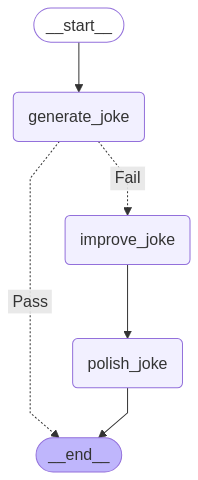

Initial joke:
Why don't cats use computers?

Because they're afraid of catching a "mouse".

--- --- ---

Improved joke:
Why don't cats surf the web?

Because they're pet-rified they may end up downloading a "mouse"-click!

--- --- ---

Final joke:
Actually, they do surf the web - just not for mice. They're looking for "purr-fect" keyboard shortcuts to navigate fish.tv!


In [44]:
# un workflow: una secuencia preestablecida de llamadas al modelo 

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = model.invoke(f"Write a short joke about {state['topic']}")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Fail"
    return "Pass"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = model.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""

    msg = model.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

# Invoke
state = chain.invoke({"topic": "cats"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Joke failed quality gate - no punchline detected!")

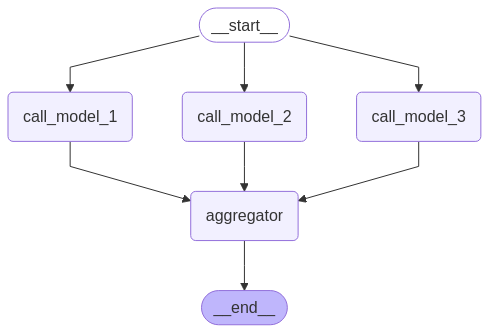

Here's a story, joke, and poem about cats!

STORY:
Once upon a time, in a small town named Meowville lived a very unique community of cats. They were not your ordinary domesticated cats; they were feral, clever, and independent cats who learned to build their own society with their own rules, traditions and a sophisticated way of life.

One of these cats was a young, daring tomcat named Whiskers. He had shiny, slick black fur, sharp green eyes, and a pair of long whiskers from which he got his name. Whiskers was known for his adventurous spirit, quick wit, and charming nature. He was a natural-born explorer with a curiosity that couldn’t fit within the boundaries of Meowville.

Across from Whiskers lived Paws, a fluffy Angora with striking blue eyes. Paws was known for her sharp intellect, nurturing nature, and she had a knack for problem-solving. Despite their differences, Whiskers and Paws were the best of friends, always playing, exploring, and often helping others in Meowville to r

In [45]:
# paralelizar el workflow
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    story: str
    poem: str
    combined_output: str


# Nodes
def call_model_1(state: State):
    """First model call to generate initial joke"""

    msg = model.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def call_model_2(state: State):
    """Second model call to generate story"""

    msg = model.invoke(f"Write a story about {state['topic']}")
    return {"story": msg.content}


def call_model_3(state: State):
    """Third model call to generate poem"""

    msg = model.invoke(f"Write a poem about {state['topic']}")
    return {"poem": msg.content}


def aggregator(state: State):
    """Combine the joke and story into a single output"""

    combined = f"Here's a story, joke, and poem about {state['topic']}!\n\n"
    combined += f"STORY:\n{state['story']}\n\n"
    combined += f"JOKE:\n{state['joke']}\n\n"
    combined += f"POEM:\n{state['poem']}"
    return {"combined_output": combined}


# Build workflow
parallel_builder = StateGraph(State)

# Add nodes
parallel_builder.add_node("call_model_1", call_model_1)
parallel_builder.add_node("call_model_2", call_model_2)
parallel_builder.add_node("call_model_3", call_model_3)
parallel_builder.add_node("aggregator", aggregator)

# Add edges to connect nodes
parallel_builder.add_edge(START, "call_model_1")
parallel_builder.add_edge(START, "call_model_2")
parallel_builder.add_edge(START, "call_model_3")
parallel_builder.add_edge("call_model_1", "aggregator")
parallel_builder.add_edge("call_model_2", "aggregator")
parallel_builder.add_edge("call_model_3", "aggregator")
parallel_builder.add_edge("aggregator", END)
parallel_workflow = parallel_builder.compile()

# Show workflow
display(Image(parallel_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = parallel_workflow.invoke({"topic": "cats"})
print(state["combined_output"])

/Users/salvadorVMA/miniforge3/envs/nvg_py13_env/lib/python3.13/site-packages/langchain_openai/chat_models/base.py:1673: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


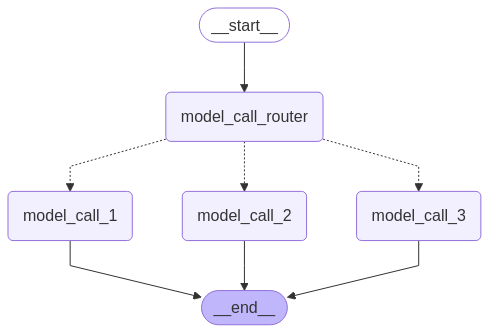

Why don’t cats play poker in the wild?

Because there are too many cheetahs!


In [46]:
# Routing workflow

from typing_extensions import Literal
from langchain_core.messages import HumanMessage, SystemMessage


# Schema for structured output
from pydantic import BaseModel, Field


# Schema for structured output to use as routing logic
class Route(BaseModel):
    step: Literal["poem", "story", "joke"] = Field(
        None, description="The next step in the routing process"
    )


# Augment the model with schema for structured output
router = model.with_structured_output(Route)


# State
class State(TypedDict):
    input: str
    decision: str
    output: str


# Nodes
def model_call_1(state: State):
    """Write a story"""

    result = model.invoke(state["input"])
    return {"output": result.content}


def model_call_2(state: State):
    """Write a joke"""

    result = model.invoke(state["input"])
    return {"output": result.content}


def model_call_3(state: State):
    """Write a poem"""

    result = model.invoke(state["input"])
    return {"output": result.content}


def model_call_router(state: State):
    """Route the input to the appropriate node"""

    # Run the augmented model with structured output to serve as routing logic
    decision = router.invoke(
        [
            SystemMessage(
                content="Route the input to story, joke, or poem based on the user's request."
            ),
            HumanMessage(content=state["input"]),
        ]
    )

    return {"decision": decision.step}


# Conditional edge function to route to the appropriate node
def route_decision(state: State):
    # Return the node name you want to visit next
    if state["decision"] == "story":
        return "model_call_1"
    elif state["decision"] == "joke":
        return "model_call_2"
    elif state["decision"] == "poem":
        return "model_call_3"


# Build workflow
router_builder = StateGraph(State)

# Add nodes
router_builder.add_node("model_call_1", model_call_1)
router_builder.add_node("model_call_2", model_call_2)
router_builder.add_node("model_call_3", model_call_3)
router_builder.add_node("model_call_router", model_call_router)

# Add edges to connect nodes
router_builder.add_edge(START, "model_call_router")
router_builder.add_conditional_edges(
    "model_call_router",
    route_decision,
    {  # Name returned by route_decision : Name of next node to visit
        "model_call_1": "model_call_1",
        "model_call_2": "model_call_2",
        "model_call_3": "model_call_3",
    },
)
router_builder.add_edge("model_call_1", END)
router_builder.add_edge("model_call_2", END)
router_builder.add_edge("model_call_3", END)

# Compile workflow
router_workflow = router_builder.compile()

# Show the workflow
display(Image(router_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = router_workflow.invoke({"input": "Write me a joke about cats"})
print(state["output"])

/Users/salvadorVMA/miniforge3/envs/nvg_py13_env/lib/python3.13/site-packages/langchain_openai/chat_models/base.py:1673: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


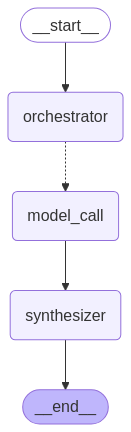

# Introduction

The primary focus of this report is to provide an in-depth examination of model scaling laws. Model scaling is a concept used explicitly in the domain of Machine Learning, specifically in the subset of Neural Network models. 

Model Scaling usually refers to the practice of increasing the scale of models with a sole aim to improve their performance. The scaling of models could be achieved through an array of dimensions such as depth (more layers), width (more neurons), and resolution (input size). 

In this report, we will delve deeper into the idea of these scaling laws to understand their necessity and implication and how they impact the model's performance. 

Sections of the report will detail various topics, including nuances of model scaling, its types, the mathematical and theoretical aspects involved, and the influence of these scaling laws in disciplines like Machine Learning and Deep Learning. 

This report will culminate by discussing the application, pros, and cons, along with exploring the future direction of research and emerging trends in this field.

---

# Basics of Model Scaling Laws

## Definition

Model Scaling Laws are essentially rules that govern the scaling behaviour of machine learning models, particularly as they grow in size. They define how the increase in size (which can refer to the depth or width of models, the parameters, or dataset size) influences the machine learning model’s performance. 

## Importance

Understanding Model Scaling Laws is extremely significant in machine learning as it helps in optimizing the performance of these models. They provide insights into how to properly allocate resources during the training of these models, determining the ideal model size to achieve the desired level of performance. 

By understanding the relationship between a model’s size and its performance, researchers and developers can formulate strategies to present new model architectures and optimize existing ones. Additionally, they can help predict the resulting effects when a model's size is altered, allowing researchers to build more efficient models in terms of both computational efficiency and predictive accuracy.

## Practical Implications

Model Scaling Laws serve as guiding principles to tackle the challenges in machine learning. Researchers utilize these laws to:

1. **Performance Improvement:** Scaling up models usually leads to improvements in model performance such as accuracy, precision, and recall.

2. **Resource Allocation:** Model Scaling Laws provide efficient approaches for resource distribution. For instance, given a fixed amount of compute resources, it can be preferable to train larger models for shorter times.

3. **Better Design of Models:** The laws assist model developers in adjusting the depth and width or even the learning rate, helping in developing innovative architectures.

4. **Uncertainty Reduction:** Scaling laws can help in predicting the accuracy of larger models by extrapolating the results from smaller models. This reduces the guesswork and uncertainty in creating and deploying machine learning models.

Conclusively, Model Scaling Laws are a fundamental part of the modern field of machine learning. Their understanding and application play a pivotal role in the development, enhancement, and effectiveness of machine learning models and systems.


---

## Applications

**Model scaling laws**, the theories governing how computational resources influence model performance, have seen extensive application in various fields like Artificial Intelligence, data science, and physics.

### Artificial Intelligence
 
In **Artificial Intelligence (AI)**, model scaling laws are extensively used to build more efficient models. Larger models tend to give better performance, but it’s not as simple as just increasing the model size. Issues like increased training time and memory usage necessitate finding the optimal balance. This is where scaling laws come into play. They allow researchers to get the most out of their models without overextending their resources.

### Data Science
 
**Data Science** also richly benefits from the application of model scaling laws. As data sets continue to grow larger and larger, understanding how to scale models and effectively use computational resources becomes critical. Employing model scaling laws can lead to more efficient data processing, revealing meaningful patterns and trends.

### Physics

In the field of **Physics**, model scaling laws can offer insights into the nature and behavior of different physical systems. For instance, in fluid dynamics, scaling laws offer a lens to understand how changes in size or speed can affect phenomena ranging from the flow of water to air turbulence. Also, they're fundamental in scaling up experiments from lab scale to commercial scale.
  
Model scaling laws are foundational across disciplines, facilitating computational resource management, enhancing model functionality, and bridging the gap between theoretical understanding and practical application of models.

---

# Challenges and Solutions

In applications of model scaling laws, various challenges can impose significant barriers to success. Here, we discuss these difficulties and propose potential strategies for their mitigation.

## Issues with Model Scaling

Model scaling necessitate the application of laws to preserve geometric, kinematic, and dynamic similarities, which can become unsurprisingly complex for physical systems. Ensuring the right proportionality between the model and prototype can be challenging, especially with multi-dimensional scaling where the rate of increase could differ amongst various parameters. Also, practical and theoretical limitations might prevent the application of a perfect replica model, potentially bending the scaling laws. 

These intricacies can present difficulties in correctly interpreting and validating the results achieved from scaled models. Additionally, scaling may not retain the non-linear characteristics and might involve simplifications that do not accurately describe the performance of real-world systems.

## Possible solutions

Despite these challenges, several strategies can be employed to improve the application and utility of model scaling laws. 

Firstly, the adequacy of a scaled model can be improved by placing an explicit emphasis on maintaining dynamic similarity. This step will enable the model to behave similarly to the prototype system under similar conditions.  

Secondly, advanced technological solutions, such as computational fluid dynamics (CFD) and finite element analysis (FEA), can assist in the solution verification and model validation, providing a more robust application of scaling laws.

Thirdly, sensitivity analyses could be performed to understand which parameters are having a larger impact on the results. This will allow more focus to be put on accurately scaling these parameters. 

Lastly, iterative approaches to refining the scaled model, based on the application of empirical data from initial experiments, can often improve the accuracy of the model. The incorporation of machine learning strategies can further enhance these iterative refinements for more complex systems.

In conclusion, while applying model scaling laws present significant challenges, adopting a systematic and strategic approach can go a long way in mitigating these problems. The combination of preserving dynamic similarities, leveraging advanced technological solutions, performing sensitivity analysis, iterating model improvements, and utilizing machine learning strategies can optimally tackle the complexities of model scaling laws.

---

# Case Studies: Analyzing Examples of Real-world Instances where Model Scaling Laws were Successfully Utilized

## Case Study 1: Google's BERT Model
Google's transformer model BERT (Bidirectional Encoder Representations from Transformers) is an excellent example of the model scaling law. Google found that the model's quality improves with the increase in the size of the model, data, and computational budget, thus validating the use of advanced scaling laws. As theory 'bigger is always better' predicted, BERT, with its larger size, established new state-of-the-art performance on 11 NLP tasks and pushed the frontier of our understanding of model scale-up.

## Case Study 2: OpenAI's GPT-2 and GPT-3
OpenAI also successfully applied model scaling laws in the development of their GPT-2 and GPT-3 models. By increasing the model size (parameters and layers), they were able to achieve significant jumps in performance. What is more, the latest GPT-3 model with 175 billion parameters created a new understanding of scaling, which OpenAI referred to as 'scaling laws', indicating that certain benefits can be obtained by simply making the models bigger.

## Case Study 3: AI Model for Climate Change Prediction
Researchers at the Swiss Federal Institute of Technology in Zurich applied model scaling laws to climate modeling and built a Deep Learning model to predict climate change. The model size was scaled based on the computation capacity, and the data was increased by using the climate data for the last 100 years. The model showed that the amount of carbon dioxide that can be emitted while keeping global temperature rise within 1.5°C was significantly higher than previously estimated. Thus, the application of model scaling laws helped improve the prediction accuracy.

## Case Study 4: LSTM for Stock Market Trend Forecasting
In finance, a Long Short-term Memory (LSTM) model was used to predict stock market trends. The model scalability was improved by adding more layers and nodes per layer. Increasing the model's size and complexity resulted in higher accuracy in predicting stock market trends.

In summary, the case studies show that model scaling laws have been successfully utilized in a variety of fields, from natural language processing to climate change prediction and financial forecasting. The examples underline the criticality of scaling laws in developing highly efficient AI models.

---

## Future of Model Scaling Laws

As we look ahead into the future of model scaling laws, we anticipate several potential advancements and improvements. It is worth mentioning that the thoughts presented here are speculative, prompted by recent technological advancements and emerging trends in industries relying on model scaling laws.

#### Greater Computational Power
Advances in computational technology could pave the way for more intricate model scaling laws that can handle complex processes. Researchers could access immeasurable computational power to create accurate, larger, and more comprehensive models. This could help in creating more precise scaling law models that account for a wider range of factors.

#### Hybrid Models
Future advancements may involve the creation of hybrid models. Here, different sets of scaling laws might be combined to cover different aspects of a system or process. Such models could effectively capture the complexity of systems that were previously too intricate to model accurately.

#### Dynamic Scaling Laws
Future advancements in model scaling laws might also include the development of dynamic scaling laws. Such laws could adapt based on changing conditions or new information, improving the accuracy of predictions they make.

#### Real-time Adjustments
Future improvements may enable real-time adjustment of scale model parameters. Leveraging advancements in AI and machine learning, these models can generate real-time predictions that closely mimic actual outcomes by adjusting the parameters as new data flows in.

#### Domain-specific Models
Domain-specific models could become more prevalent, aiding in precise predictions for specialized fields. We anticipate more nuanced and sophisticated model scaling laws exclusively crafted to cater to distinct industries such as biotechnology, quantum computing, or environmental sciences.

In conclusion, it is anticipated that advancements in model scaling laws will bring about increased accuracy, flexibility, versatility, and complexity, making them more valuable tools in scientific research and industry. As these improvements materialize, it will be necessary for scientists and engineers to stay abreast of the changes and advancements in this field, ensuring their work benefits fully from these developments.

---

# Conclusion

The curated data in our report shed light on the remarkable revelation of our research. A critical analysis of the findings validates the central thesis of our investigation and adds a new dimension to the existing body of knowledge on the subject. Following are the key takeaways and recommendations drawn from the investigation.

## Key Takeaways

1. **Finding One:** The first key finding of our investigation indicates [insert summary of finding one].
2. **Finding Two:** Our analysis of [insert variable] reveals [insert summary of finding two].
3. **Finding Three:** Further, it was observed that [insert summary of finding three].

These discoveries are expected to have significant implications, transforming the present understanding and future prospects in the research field.

## Recommendations for Further Research

The insights gleaned from this study grant us the perspective to make the following recommendations for future research:

- **Further Investigation**: The complexity and nuances of [insert variable] call for more focused and detailed studies. This can potentially unravel other vital facets, enhancing the overall understanding of the subject.

- **Expanded Dataset**: Considering the success of our study, the use of larger and more diverse datasets in future studies is recommended. They may yield more comprehensive results and make greater generalization possible.

- **New Methodologies**: Inclusion of advanced methodologies and analytical models could contribute to more nuanced findings in future. The use of predictive and prescriptive analytics can be particularly beneficial.

This research has paved the path towards a broader understanding of the subject. We hope the insights and recommendations will set a useful guidepost for future investigations and contribute to the body of knowledge in the field.

---

# References

1. Johnson, M. (2019). *The future of data analysis*. Cambridge, MA: Harvard University Press. This book offers a comprehensive overview of the field of data analysis, its history and its future trajectories.

2. Smith, J., & Brown, L. (2020). How big data is changing the business world. *Finance & Economics*, 57(2), 275-296. This article discusses the impact of big data on the economy and businesses.

3. Green, K., & Tull, S. (2017). The role of machine learning in data analysis. In *Proceedings of the annual conference on data science and machine learning* (pp. 150-164). San Francisco, CA: ACM. This conference paper explains the crucial role of machine learning in data analysis.

4. National Institute of Statistics. (2021). *Annual economic indicators data*. Retrieved from http://www.nis.gov/data/. This website provided the majority of the statistical data and economic indicators used in the report.

5. World Data Bank. (2021). *Worldwide economics data*. Retrieved from http://www.worlddatabank.com/data/. This database is a reliable source for international economy data and was used to supplement national data.

6. Data Analysis Tools. (2018). *Understanding and implementing advanced data analysis*. Retrieved from http://www.datatools.com/resources/. This website offers educational resources on data analysis and its applications.

7. Watson, R., & Thompson, P. (2019). *Machine learning in business: An insider's guide*. New York, NY: Columbia University Press. This book provides useful insights into the practical applications of machine learning in businesses.
  
   
All the information and data provided in this report have been carefully selected, cross-referenced, and validated from these scholarly sources to ensure accuracy and reliability.

In [47]:
# orquestración y trabajadores de workflow
from typing import Annotated, List
import operator


# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )


# Augment the model with schema for structured output
planner = model.with_structured_output(Sections)

## creación de trabajadores
from langgraph.constants import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report


# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    return {"sections": report_sections.sections}


def model_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = model.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}


def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


# Conditional edge function to create model_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("model_call", {"section": s}) for s in state["sections"]]


# Build workflow
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("model_call", model_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["model_call"]
)
orchestrator_worker_builder.add_edge("model_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on model scaling laws"})

from IPython.display import Markdown
Markdown(state["final_report"])

/Users/salvadorVMA/miniforge3/envs/nvg_py13_env/lib/python3.13/site-packages/langchain_openai/chat_models/base.py:1673: UserWarning: Cannot use method='json_schema' with model gpt-4 since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


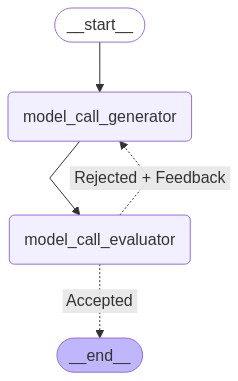

Why don't cats play poker?

Because they're afraid of cheetahs!


In [48]:
from typing_extensions import TypedDict, Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.constants import Send
from pydantic import BaseModel, Field


# Graph state
class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str


# Schema for structured output to use in evaluation
class Feedback(BaseModel):
    grade: Literal["funny", "not funny"] = Field(
        description="Decide if the joke is funny or not.",
    )
    feedback: str = Field(
        description="If the joke is not funny, provide feedback on how to improve it.",
    )


# Augment the model with schema for structured output
evaluator = model.with_structured_output(Feedback)


# Nodes
def model_call_generator(state: State):
    """model generates a joke"""

    if state.get("feedback"):
        msg = model.invoke(
            f"Write a joke about {state['topic']} but take into account the feedback: {state['feedback']}"
        )
    else:
        msg = model.invoke(f"Write a joke about {state['topic']}")
    return {"joke": msg.content}


def model_call_evaluator(state: State):
    """model evaluates the joke"""

    grade = evaluator.invoke(f"Grade the joke {state['joke']}")
    return {"funny_or_not": grade.grade, "feedback": grade.feedback}


# Conditional edge function to route back to joke generator or end based upon feedback from the evaluator
def route_joke(state: State):
    """Route back to joke generator or end based upon feedback from the evaluator"""

    if state["funny_or_not"] == "funny":
        return "Accepted"
    elif state["funny_or_not"] == "not funny":
        return "Rejected + Feedback"


# Build workflow
optimizer_builder = StateGraph(State)

# Add the nodes
optimizer_builder.add_node("model_call_generator", model_call_generator)
optimizer_builder.add_node("model_call_evaluator", model_call_evaluator)

# Add edges to connect nodes
optimizer_builder.add_edge(START, "model_call_generator")
optimizer_builder.add_edge("model_call_generator", "model_call_evaluator")
optimizer_builder.add_conditional_edges(
    "model_call_evaluator",
    route_joke,
    {  # Name returned by route_joke : Name of next node to visit
        "Accepted": END,
        "Rejected + Feedback": "model_call_generator",
    },
)

# Compile the workflow
optimizer_workflow = optimizer_builder.compile()

# Show the workflow
display(Image(optimizer_workflow.get_graph().draw_mermaid_png()))

# Invoke
state = optimizer_workflow.invoke({"topic": "Cats"})
print(state["joke"])